In [47]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [48]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 32

TRAIN_DIR = r"C:/Users/Asus/Downloads/Dataset/Train"
VAL_DIR = r"C:/Users/Asus/Downloads/Dataset/Validation"
TEST_DIR = r"C:/Users/Asus/Downloads/Dataset/Test"

datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 8664 images belonging to 2 classes.
Found 6352 images belonging to 2 classes.
Found 2877 images belonging to 2 classes.


In [50]:
print(train_generator.class_indices)

{'Fake': 0, 'Real': 1}


In [51]:
import os

print(os.listdir(r"C:/Users/Asus/Downloads/Dataset"))

print(os.listdir(r"C:/Users/Asus/Downloads/Dataset/Train"))

['Test', 'Train', 'Validation']
['Fake', 'Real']


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),
    
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [53]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [54]:
history = model.fit(
    train_generator,
    validation_data=val_generator, 
    epochs=15
)

Epoch 1/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 117s 423ms/step - accuracy: 0.7023 - loss: 0.5673 - val_accuracy: 0.7491 - val_loss: 0.4961
Epoch 2/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 58s 215ms/step - accuracy: 0.7988 - loss: 0.4367 - val_accuracy: 0.7763 - val_loss: 0.4575
Epoch 3/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 58s 215ms/step - accuracy: 0.8404 - loss: 0.3637 - val_accuracy: 0.8051 - val_loss: 0.4103
Epoch 4/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 60s 221ms/step - accuracy: 0.8719 - loss: 0.2992 - val_accuracy: 0.8297 - val_loss: 0.3786
Epoch 5/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 59s 216ms/step - accuracy: 0.9018 - loss: 0.2347 - val_accuracy: 0.8300 - val_loss: 0.3829
Epoch 6/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 58s 214ms/step - accuracy: 0.9283 - loss: 0.1758 - val_accuracy: 0.8408 - val_loss: 0.3913
Epoch 7/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 59s 218ms/step - accuracy: 0.9466 - loss: 0.1354 - val_accuracy: 0.8482 - val_loss: 0.4155
Epoch 8/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 59s 217ms/step - accuracy: 0.9591 - loss: 

In [55]:
loss, accuracy = model.evaluate(val_generator)

print("Accuracy:", accuracy)

199/199 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.8490 - loss: 0.8923
Accuracy: 0.8490239381790161


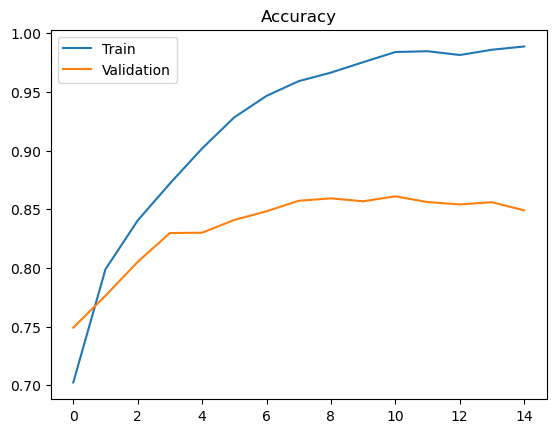

In [56]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

In [57]:
model.save("deepfake_detector.h5")

In [93]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
   "C:/Users/Asus/Downloads/ChatGPT Image Mar 30, 2025, 10_10_52 PM.png",
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[0.27572078]]


In [94]:
prediction = model.predict(img_array)[0][0]

# Since your mapping is:
# 0 = Fake, 1 = Real
real_prob = prediction
fake_prob = 1 - prediction

print(f"Real probability: {real_prob:.4f}")
print(f"Fake probability: {fake_prob:.4f}")

if real_prob >= 0.75:
    print("✅ Real Image (High Confidence)")
elif real_prob <= 0.25:
    print("❌ Fake Image (High Confidence)")
else:
    print("⚠️ Uncertain Image (Low Confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Real probability: 0.2757
Fake probability: 0.7243
⚠️ Uncertain Image (Low Confidence)


In [95]:
threshold = 0.65  # stricter than 0.5

if real_prob > threshold:
    print("Real Image")
elif real_prob < (1 - threshold):
    print("Fake Image")
else:
    print("Needs Human Review")

Fake Image


In [82]:
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

In [83]:
base_model.trainable = False

In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [85]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [86]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 111s 390ms/step - accuracy: 0.7351 - loss: 0.5333 - val_accuracy: 0.8095 - val_loss: 0.4113
Epoch 2/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 86s 316ms/step - accuracy: 0.7876 - loss: 0.4467 - val_accuracy: 0.8016 - val_loss: 0.4202
Epoch 3/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 99s 367ms/step - accuracy: 0.8015 - loss: 0.4226 - val_accuracy: 0.7912 - val_loss: 0.4306
Epoch 4/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 88s 326ms/step - accuracy: 0.8127 - loss: 0.4041 - val_accuracy: 0.8013 - val_loss: 0.4110
Epoch 5/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 99s 365ms/step - accuracy: 0.8249 - loss: 0.3812 - val_accuracy: 0.8155 - val_loss: 0.3984
Epoch 6/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 99s 365ms/step - accuracy: 0.8328 - loss: 0.3593 - val_accuracy: 0.8023 - val_loss: 0.4223
Epoch 7/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 94s 347ms/step - accuracy: 0.8408 - loss: 0.3414 - val_accuracy: 0.8122 - val_loss: 0.4136
Epoch 8/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 92s 340ms/step - accuracy: 0.8528 - loss: 

In [87]:
loss, acc = model.evaluate(test_generator)

print("Test Accuracy:", acc)

90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 251ms/step - accuracy: 0.7303 - loss: 0.6847
Test Accuracy: 0.7302746176719666


In [88]:
model.save("deepfake_mobilenetv2.h5")

In [92]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"C:/Users/Asus/Downloads/ChatGPT Image Mar 30, 2025, 10_10_52 PM.png"
# 🔥 Match model input size
img = image.load_img(img_path, target_size=(128, 128))

img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

prediction = model.predict(img_array)[0][0]

real_prob = float(prediction)
fake_prob = float(1 - prediction)

if real_prob >= 0.75:
    label = "Real Image (High Confidence)"
    status = "REAL"
elif real_prob <= 0.25:
    label = "Fake Image (High Confidence)"
    status = "FAKE"
else:
    label = "Uncertain Prediction"
    status = "UNCERTAIN"

print("Status:", status)
print("Real %:", real_prob * 100)
print("Fake %:", fake_prob * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Status: UNCERTAIN
Real %: 27.57207751274109
Fake %: 72.42792248725891
